# TeleConnect Churn Prediction - Part 1
This notebook contains the complete data cleaning, exploratory data analysis (EDA), and model building pipeline for TeleConnect's customer churn prediction.

In [2]:
import pandas as pd
import sys
import os
sys.path.append(os.path.join(os.getcwd(), "..", "src"))
from data_processing import run_cleaning_pipeline, build_quality_summary
from model_building import compute_feature_associations, plot_eda_charts, engineer_features, prepare_train_test, train_logistic, train_xgboost, evaluate_model, plot_confusion_matrix, plot_roc_curves, plot_feature_importance, export_model_artifacts

import warnings
warnings.filterwarnings('ignore')

## 1.1 Data Quality Assessment and Cleaning
The marketing team provided a raw dataset with known quality issues (e.g., system migrations, manual entry errors).
Our cleaning pipeline systematically addresses impossible values (like negative age), normalizes categorical strings, corrects cross-field logical conflicts, and imputes missing data. Below is the summary table of the corrections.

In [3]:
raw_file = '../data/test_datafile.csv'
df_cleaned = run_cleaning_pipeline(raw_file)
print("\n--- Quality Summary ---")
build_quality_summary(raw_file, df_cleaned)

Loaded 5050 rows from test_datafile.csv
Cleaning complete. Final shape: (5050, 53)

--- Quality Summary ---
Raw shape: (5050, 17) | Cleaned shape: (5050, 53)

Column                    Issue                                              Before                                        After
----------------------------------------------------------------------------------------------------------------------------------
age                       Impossible/missing values                          nulls=10                                      nulls=0
gender                    Spelling variants, missing data                    8 unique values                               OHE applied
total_charges             Low vs expected billing                            Rows off by >70%                              Corrected & flagged
internet_service          String nan, variants                               ['DSL', 'Fiber optic', 'No', 'fiber', 'dsl']  OHE applied
satisfaction_score        Values > 10

## 1.2 Exploratory Data Analysis
To understand the relationship between our features and churn, we compute the point-biserial correlation for all numeric and encoded categorical features.
We also visualize three key relationships:
1. **Contract Type**: Month-to-month contracts have the highest churn.
2. **Tenure**: Early-tenure customers are at the highest risk.
3. **Satisfaction Score**: Low satisfaction directly doubles the churn probability.

Point-biserial correlation with churn (Top 15):
1. conflict_inactive_retained: r=-0.9983, p=0.0
2. contract_type: r=-0.2676, p=0.0
3. conflict_satisfaction_churn: r=0.2643, p=0.0
4. satisfaction_score: r=-0.129, p=0.0
5. tenure_months: r=-0.0798, p=0.0
6. is_dissatisfied: r=0.0717, p=0.0
7. conflict_contract_tenure: r=-0.0455, p=0.0012
8. total_charges: r=-0.0446, p=0.0015
9. is_high_ticket: r=0.0416, p=0.0031
10. satisfaction_was_missing: r=-0.0354, p=0.0118
11. tenure_is_new_customer: r=0.0343, p=0.0147
12. gender_Male: r=0.033, p=0.0189
13. gender_Female: r=-0.0291, p=0.0385
14. has_any_tickets: r=0.0258, p=0.0671
15. internet_Fiber optic: r=0.0232, p=0.099


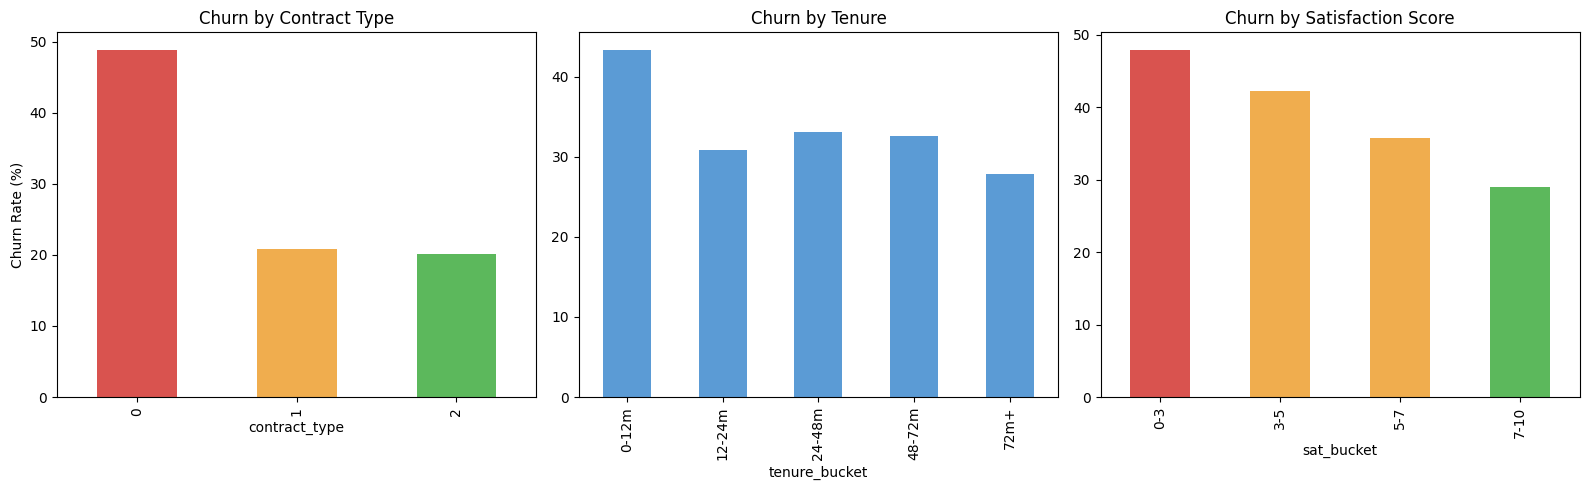

Saved eda_charts.png


In [4]:
associations = compute_feature_associations(df_cleaned)
plot_eda_charts(df_cleaned)

### Feature Engineering
We engineer two new features to improve model performance:
1. **`charges_per_month_ratio`**: Normalizes total lifetime spend by the active tenure to catch bill shock.
2. **`risk_score_composite`**: A simple weighted blend of satisfaction, contract type, and tenure, enabling retention reps to quickly glance at a non-model risk score.

In [5]:
df_engineered = engineer_features(df_cleaned)

## 1.3 Model Building and Evaluation
We train two distinct models:
- **Logistic Regression**: A linear model that provides excellent baseline interpretability. Class imbalance is addressed using `class_weight='balanced'`.
- **XGBoost**: A powerful tree-based ensemble model capable of capturing complex non-linear relationships. We address class imbalance via `scale_pos_weight`.

**Metric Selection**: For churn prediction, **Recall** is arguably the most critical metric. Missing a churner (False Negative) results in lost revenue, whereas a False Positive only results in an unnecessary retention offer (a low-cost intervention).

In [6]:
X_train, X_test, y_train, y_test, scaler = prepare_train_test(df_engineered)

lr_model = train_logistic(X_train, y_train)
xgb_model = train_xgboost(X_train, y_train)

print("Evaluating Logistic Regression:")
lr_proba = evaluate_model("Logistic Regression", lr_model, X_test, y_test)

print("\nEvaluating XGBoost:")
xgb_proba = evaluate_model("XGBoost", xgb_model, X_test, y_test)

Evaluating Logistic Regression:

Logistic Regression - AUC: 0.7179
              precision    recall  f1-score   support

           0       0.80      0.59      0.68       643
           1       0.51      0.74      0.60       367

    accuracy                           0.64      1010
   macro avg       0.65      0.66      0.64      1010
weighted avg       0.69      0.64      0.65      1010


Evaluating XGBoost:

XGBoost - AUC: 0.7009
              precision    recall  f1-score   support

           0       0.76      0.68      0.72       643
           1       0.52      0.62      0.57       367

    accuracy                           0.66      1010
   macro avg       0.64      0.65      0.64      1010
weighted avg       0.67      0.66      0.66      1010



## 1.4 Visualizations
Below are the visualizations evaluating the performance of the XGBoost model and comparing the ROC curves of both models.

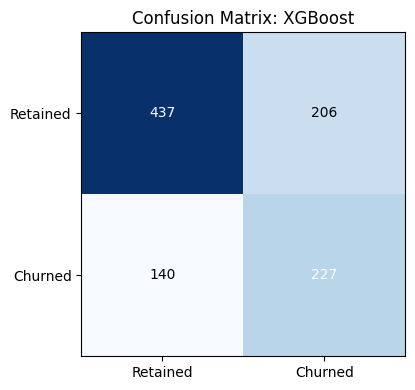

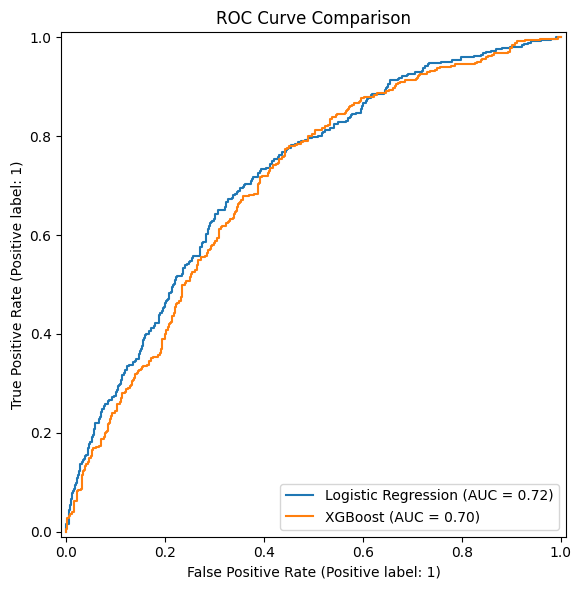

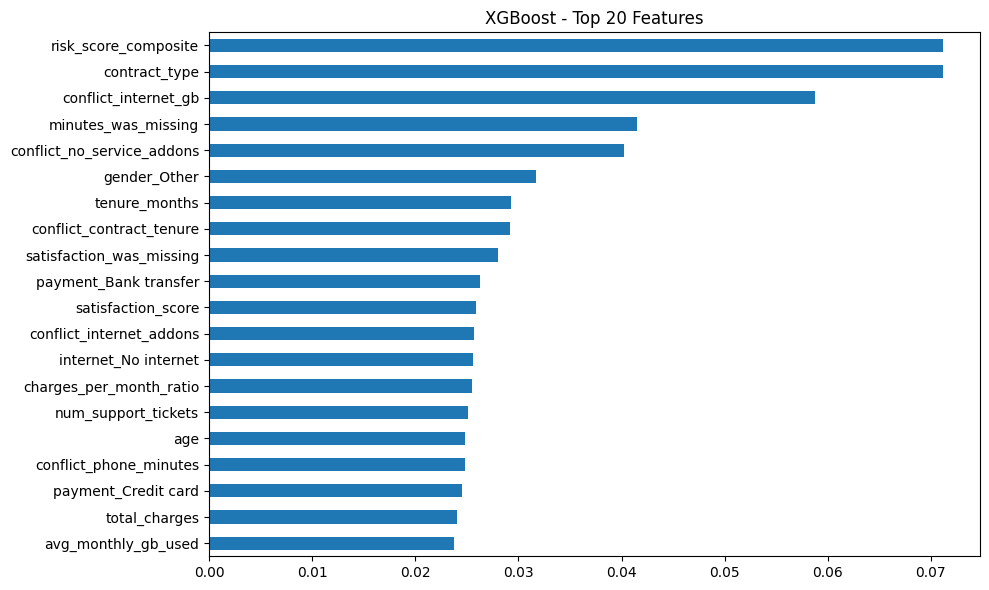

In [7]:
plot_confusion_matrix(xgb_model, X_test, y_test, "XGBoost")
plot_roc_curves({"Logistic Regression": lr_proba, "XGBoost": xgb_proba}, y_test)
plot_feature_importance(xgb_model, X_train.columns.tolist())

## 1.5 Export Model for Part 2
Finally, we save the trained models, the scaler, and the feature lists as `.pkl` artifacts so they can be loaded by the retention agent in Part 2.

In [8]:
export_model_artifacts(xgb_model, lr_model, scaler, X_train.columns.tolist())

Artifacts saved to ./models/
